# Autocorrelation

In [7]:
import pandas as pd
import numpy as np
import datetime
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme(palette="Set2")

In [8]:
def random_walk(obs=100, m=0, stdev=0.5, d=1):
    """
    :param: obs: number of observations
    :param: m: mean
    :param: stdev: standard deviation
    :param: d: number of dimensions
    """
    return np.cumsum(np.random.normal(m, stdev, (obs, d)))

def white_noise(obs=100, m=0, stdev=0.5, d=1):
    return np.random.normal(m, stdev, (obs, d)).flatten()

def red_noise(obs=100, m=0, stdev=0.5, d=1, corr=0.7):
    white = white_noise(obs, m, stdev, d)
    red = np.zeros_like(white)
    for i in range(1, len(white)):
        red[i] = corr * red[i-1] + white[i]
    return red

def linear_trend(obs=100, d=1, y_start=0, y_stop=10):
    return np.linspace(start=y_start, stop=y_stop, num=obs).reshape(-1, 1).flatten()

def seasonality(obs=100, d=1, period=7, y_max=2):
    """
    :param: obs: number of observations
    :param: d: number of dimensions
    :param: period: period of the seasonal component
    :param: y_max: maximum value of the seasonal component
    """
    t = np.arange(obs)
    return y_max * np.sin(2 * np.pi * t / period).reshape(-1, d).flatten()

def structural_break(t, break_point=50, size=2):
    """:param: t: time points
    :param: break_point: index where the structural break occurs
    """
    t[break_point:] += size 
    return t

def segmented_trend(obs=100, y_start=0, y_stop=10, d=1, 
                    segment_start=0.5, segment_end=0.7, segment_y_start=1, segment_y_stop=5):
    segment_start = int(segment_start*obs)
    segment_end = int(segment_end*obs)
    t1 = linear_trend(segment_start, d, y_start=y_start, y_stop=segment_y_start)
    t2 = linear_trend(segment_end - segment_start, d, y_start=segment_y_start, y_stop=segment_y_stop)
    t3 = linear_trend(obs - segment_end, d, y_start=segment_y_stop, y_stop=y_stop)
    t = np.concatenate([t1, t2, t3])
    return t

def anomalies(t, anomaly_point=70, size=2):
    t[anomaly_point] += size  
    return t

# Autocorrelation Function Plot

In [9]:
nobs = 365 * 2
rn = red_noise(nobs, corr=0.7)

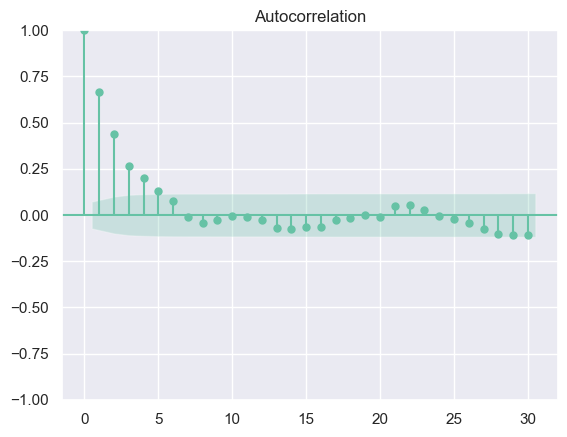

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

_ = plot_acf(rn, lags=30)

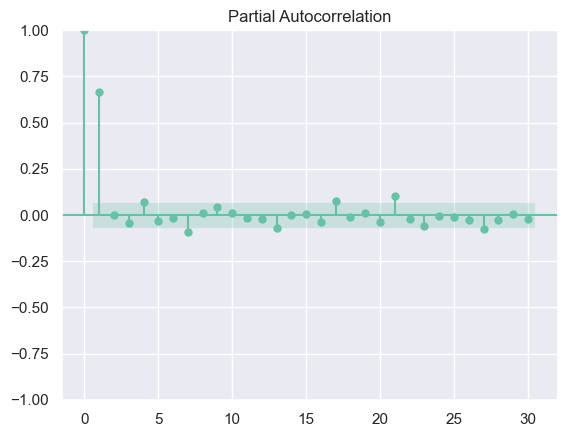

In [11]:
_ = plot_pacf(rn, lags=30)

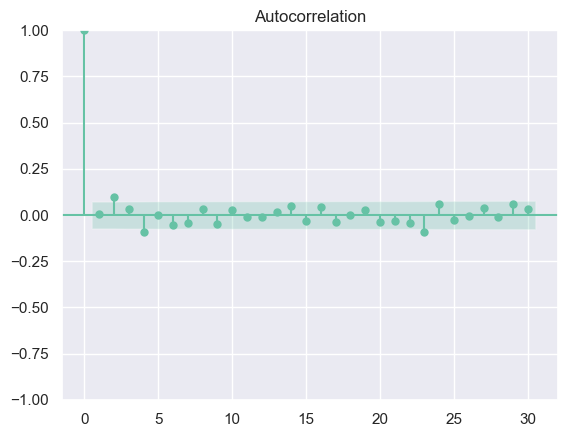

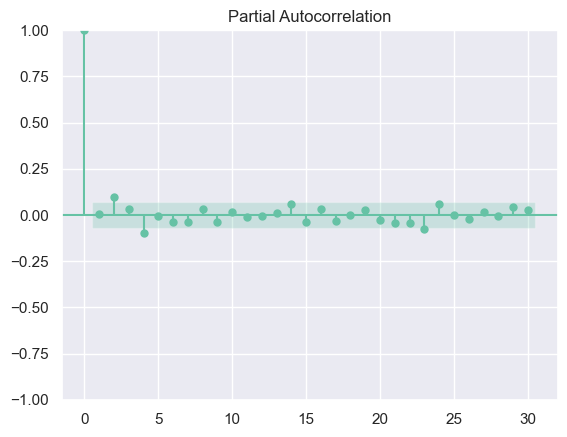

In [12]:
wn = white_noise(nobs)
_ = plot_acf(wn, lags=30)
_ = plot_pacf(wn, lags=30)